In [ ]:
# Outliers are the points of the data that fluctuate the mean of dataset.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('newplacementdata.csv')
df.head(3)

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1


In [3]:
# Even = ((n/2) + ((n/2) + 1))/2
# Odd = ((n/2) + 1)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

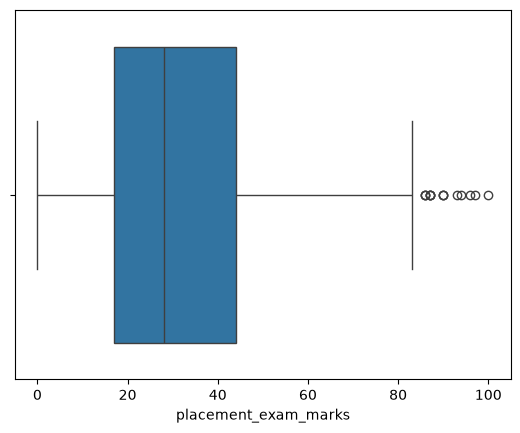

In [ ]:
sns.boxplot(x = df['placement_exam_marks']) #After 80 the points are outliers

In [7]:
# Finding IQR(Inter quartile range)

percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

print("percentile25 is :",percentile25)
print("percentile75 is :",percentile75)

percentile25 is : 17.0
percentile75 is : 44.0


As you see that 17.0 is the percentile25 that in lower

and, for percentile75 is 44.0

In [ ]:
# finding IQR
IQR = percentile75 - percentile25  # Means the middle line of boxplot is 27
IQR

27.0

In [9]:
# for getting upper limit and lower limit we have formula 1.5*IQR

In [10]:
upper_limit = percentile75 + 1.5*IQR
upper_limit

84.5

In [13]:
lower_limit = percentile25 - 1.5*IQR
lower_limit

-23.5

Finding our outliers

In [14]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94,1
40,6.60,86,1
61,7.51,86,0
134,6.33,93,0
162,7.80,90,0
283,7.09,87,0
290,8.38,87,0
311,6.97,87,1
324,6.64,90,0
630,6.56,96,1


In [16]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


In [17]:
# To handle the outliers we have two method :-

# Trimming and capping

In [19]:
newdf = df[df['placement_exam_marks'] < upper_limit]
newdf

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1
3,6.42,8,1
4,7.23,17,0
...,...,...,...
995,8.87,44,1
996,9.12,65,1
997,4.89,34,0
998,8.62,46,1


In [20]:
# comparison 

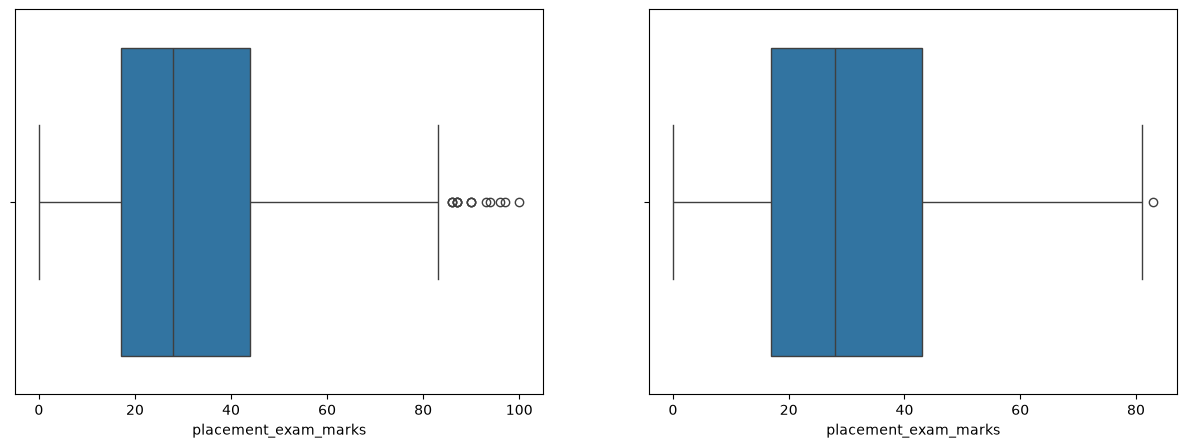

In [25]:
plt.figure(figsize=(15, 5))

plt.subplot(121)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(122)
sns.boxplot(x=newdf['placement_exam_marks'])

plt.show()

In [26]:
# Capping (Outlier removing technique 2) :- It used to expand the range

In [27]:
new_df_cap = df.copy()

In [ ]:
# min ---> 5, max --->15

# min ---> 4,3,2,1
# max ---> 20,30,50

# updated_min_value = 1
# updated_max_value = 50

In [28]:
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,

    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [29]:
new_df_cap

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [30]:
new_df_cap.shape

(1000, 3)

In [31]:
# Comparison

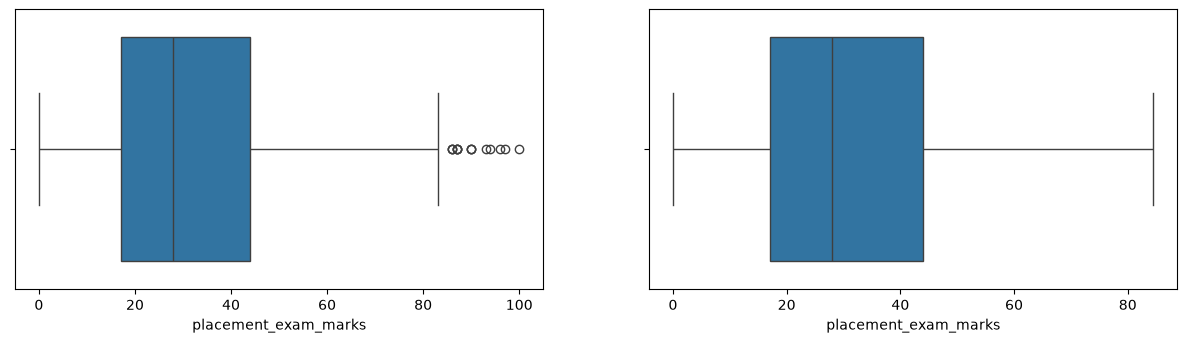

In [34]:
plt.figure(figsize=(15, 8))

plt.subplot(221)

sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(222)

sns.boxplot(x=new_df_cap['placement_exam_marks'])

plt.show()

In [ ]:
# As you see that there is no outlier after applying capping